# SHAP Error Analysis & Microscopic Evaluation — CS3244 Group 23

**Part A — SHAP Analysis**
Identify which engineered spread features drive predictions across all regressive models, and confirm alignment with mean-reversion economic intuition.

**Part B — Microscopic Evaluation**
Examine 5 successful and 5 failed trades from the best-performing model (LSTM Encoder-Decoder Kalman by DWMSE; XGBoost Kalman used here as the interpretable proxy) to explain the gap between forecast accuracy and trading performance.

**Dataset:** Holdout window `2014_2016` — trained 2014–2016, evaluated on 2017 test set.

**Best model (by holdout MSE):** Linear Regression Kalman (MSE = 0.000759). XGBoost Kalman is a close second (MSE = 0.000777) and is used as the interpretable proxy in Part B. DWMSE is the primary selection metric within each model family (Kalman vs OLS); the cross-model DWMSE ranking aligns with the MSE ranking since Kalman variants achieve both lower MSE and higher directional accuracy across all families.

**Primary metric:** DWMSE (Directional-Weighted MSE) — wrong-direction errors penalised 2×. Secondary metrics: MSE, MAE, RMSE, Directional Accuracy.

**Features (11):**
| Feature | Economic Meaning | Expected Importance |
|---|---|---|
| `z_score` | OLS spread deviation from 60d mean | ⭐ HIGH |
| `z_score_kalman` | Kalman spread deviation | ⭐ HIGH |
| `days_since_crossing` | Days since last mean cross | ⭐ HIGH |
| `momentum_5d` | 5-day spread change | LOW — arbitrary lag |
| `momentum_10d` | 10-day spread change | LOW — arbitrary lag |
| `rolling_vol_20d` | 20d spread volatility | MEDIUM — regime |
| `rolling_vol_60d` | 60d spread volatility | MEDIUM — regime |
| `rolling_corr_60d` | 60d rolling correlation | MEDIUM — pair stability |
| `kalman_beta` | Current Kalman hedge ratio | MEDIUM |
| `kalman_beta_change` | 5-day change in hedge ratio | MEDIUM — relationship drift |
| `spread_acceleration` | Second derivative of spread | LOW |


---
# PART A — SHAP ANALYSIS

## 0. Setup

In [75]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import shap

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print(f'PyTorch available: {torch.__version__}')
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch NOT available — LSTM sections will be skipped. pip install torch')

print(f'SHAP:    {shap.__version__}')
print(f'XGBoost: {xgb.__version__}')

# ── Paths ─────────────────────────────────────────────────────────────────
# Import ROOT and holdout label from config.py so paths are never duplicated.
import sys
sys.path.insert(0, str(Path(__file__).resolve().parent if '__file__' in dir() else Path.cwd()))
try:
    from config import DEFAULT_CONFIG
    ROOT           = DEFAULT_CONFIG.project_root
    _holdout_label = DEFAULT_CONFIG.holdout_split.label          # '2014_2016'
    print(f'config.py loaded — ROOT: {ROOT}')
except ImportError:
    # Fallback: auto-discover repo root the old way
    def _find_repo_root(start: Path) -> Path:
        for candidate in [start, *start.parents]:
            if (candidate / 'run_pipeline.ps1').exists() and (candidate / 'src').exists():
                return candidate
        raise FileNotFoundError('Could not locate repo root. Ensure config.py is on sys.path.')
    ROOT           = _find_repo_root(Path.cwd().resolve())
    _holdout_label = '2014_2016'
    print(f'config.py not found — fell back to repo-root discovery: {ROOT}')

DATA_PROCESSED = ROOT / 'data' / 'processed'
TRAIN_PATH = DATA_PROCESSED / 'pair_datasets' / _holdout_label / 'train_pair_dataset.csv'
TEST_PATH  = DATA_PROCESSED / 'pair_datasets' / _holdout_label / 'test_pair_dataset.csv'

TARGET_OLS    = 'label_continuous_10d'
TARGET_KALMAN = 'label_kalman_10d'

FEATURE_COLS = [
    'z_score', 'z_score_kalman', 'momentum_5d', 'momentum_10d',
    'rolling_vol_20d', 'rolling_vol_60d', 'rolling_corr_60d',
    'days_since_crossing', 'kalman_beta', 'kalman_beta_change',
    'spread_acceleration',
]
MEAN_REVERSION_FEATURES = ['z_score', 'z_score_kalman', 'days_since_crossing']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
print('\nSetup complete.')

PyTorch available: 2.11.0+cpu
SHAP:    0.51.0
XGBoost: 3.2.0
config.py not found — fell back to repo-root discovery: C:\Users\cathe\Documents (Main)\NUS folder\Pairs-Trading

Setup complete.


In [76]:
# ── Load Hyperparameters from Tuning Artefacts ────────────────────────────
#
# XGBoost  — ROOT/data/processed/predictions/xgboost_{ols|kalman}/best_params.csv
#   Layout (wide): param names are column headers, values in first data row.
#   Extra metadata columns (e.g. 'spread_type') are automatically stripped.
#
# LSTM/ED  — ROOT/data/processed/predictions/lstm_{variant}/tuning_results.csv
#            Columns: hidden_size, window_size, learning_rate, avg_val_mse, ...
#            Best row selected by lowest avg_val_mse.
#
# Architecture constants (NOT grid-searched — fixed design choices):
#   num_layers=2, dropout=0.2, batch_size=128, epochs=50, patience=7, horizon=10
# ──────────────────────────────────────────────────────────────────────────

PRED_DIR = DATA_PROCESSED / 'predictions'

_ARCH    = dict(num_layers=2, dropout=0.2, batch_size=128, epochs=50, patience=7)
_INT_XGB = {'max_depth', 'n_estimators', 'min_child_weight'}

# Columns that may appear in best_params.csv but are NOT XGBoost hyperparameters.
# These are stripped before passing params to XGBRegressor.
_XGB_META_COLS = {'spread_type', 'variant', 'fold', 'trial', 'avg_val_mse',
                  'best_iteration', 'label', 'model', 'target'}

def _load_xgb_best(variant: str) -> dict:
    path = PRED_DIR / f'xgboost_{variant}' / 'best_params.csv'
    df   = pd.read_csv(path)
    # Wide format: param names are column headers, first row has the values.
    raw = df.iloc[0].to_dict()
    out = {}
    for k, v in raw.items():
        k = str(k).strip()
        if k in _XGB_META_COLS:
            continue          # skip metadata columns
        try:
            out[k] = int(float(v)) if k in _INT_XGB else float(v)
        except (ValueError, TypeError):
            pass              # skip unparseable values silently
    return out

def _load_lstm_best(variant: str) -> dict:
    path = PRED_DIR / f'lstm_{variant}' / 'tuning_results.csv'
    df   = pd.read_csv(path)
    row  = df.loc[df['avg_val_mse'].idxmin()]
    return {
        'hidden_size':   int(row['hidden_size']),
        'window_size':   int(row['window_size']),
        'learning_rate': float(row['learning_rate']),
        **_ARCH,
    }

# ── XGBoost ────────────────────────────────────────────────────────────────
try:
    XGB_BEST_OLS    = _load_xgb_best('ols')
    XGB_BEST_KALMAN = _load_xgb_best('kalman')
except Exception as e:
    print(f'WARNING: {e} — using hardcoded XGBoost fallback.')
    XGB_BEST_OLS    = {'max_depth': 3, 'n_estimators': 100, 'learning_rate': 0.01}
    XGB_BEST_KALMAN = {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.01}

# Shared XGBoost params (regularisation / sampling — not variant-specific)
XGB_SHARED = dict(subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  reg_lambda=1.0, objective='reg:squarederror', random_state=42, verbosity=0)
XGB_BEST_OLS.pop('min_child_weight', None)     # avoid duplicate-key conflict with SHARED
XGB_BEST_KALMAN.pop('min_child_weight', None)

# ── LSTM / Encoder-Decoder ────────────────────────────────────────────────
try:
    _lstm_ols = _load_lstm_best('ols')
    _lstm_kal = _load_lstm_best('kalman')
    _ed_ols   = _load_lstm_best('encoder_decoder_ols')
    _ed_kal   = _load_lstm_best('encoder_decoder_kalman')
except Exception as e:
    print(f'WARNING: {e} — using hardcoded LSTM fallback.')
    _lstm_ols = _lstm_kal = _ed_ols = _ed_kal = dict(
        hidden_size=64, window_size=20, learning_rate=0.001, **_ARCH)

# ── Expose via BEST_PARAMS dict ───────────────────────────────────────────
# Includes 'xgboost' key so Part B (microscopic analysis) can reference it.
BEST_PARAMS = {
    'xgboost': {
        'ols':    {**XGB_BEST_OLS,    **XGB_SHARED},
        'kalman': {**XGB_BEST_KALMAN, **XGB_SHARED},
    },
    'lstm':                 _lstm_ols,
    'lstm_kalman':          _lstm_kal,
    'lstm_encoder_decoder': {**_ed_kal, 'horizon': 10},
    'lstm_ed_ols':          {**_ed_ols,  'horizon': 10},
}

print('Hyperparameters loaded:')
print(f'  XGBoost OLS    : {XGB_BEST_OLS}')
print(f'  XGBoost Kalman : {XGB_BEST_KALMAN}')
print(f'  LSTM OLS       : {_lstm_ols}')
print(f'  LSTM Kalman    : {_lstm_kal}')
print(f'  ED   OLS       : {_ed_ols}')
print(f'  ED   Kalman    : {_ed_kal}')


Hyperparameters loaded:
  XGBoost OLS    : {'max_depth': 3, 'n_estimators': 100, 'learning_rate': 0.01}
  XGBoost Kalman : {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.01}
  LSTM OLS       : {'hidden_size': 64, 'window_size': 20, 'learning_rate': 0.001, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 128, 'epochs': 50, 'patience': 7}
  LSTM Kalman    : {'hidden_size': 32, 'window_size': 20, 'learning_rate': 0.001, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 128, 'epochs': 50, 'patience': 7}
  ED   OLS       : {'hidden_size': 32, 'window_size': 20, 'learning_rate': 0.0005, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 128, 'epochs': 50, 'patience': 7}
  ED   Kalman    : {'hidden_size': 64, 'window_size': 20, 'learning_rate': 0.001, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 128, 'epochs': 50, 'patience': 7}


## 1. Load Data

In [77]:
train_df = pd.read_csv(TRAIN_PATH, parse_dates=['Date'])
test_df  = pd.read_csv(TEST_PATH,  parse_dates=['Date'])

print(f'Train: {train_df.shape[0]:,} rows | {train_df["pair"].nunique()} pairs')
print(f'Test:  {test_df.shape[0]:,} rows  | {test_df["pair"].nunique()} pairs')

def get_Xy(df, target_col):
    """Drop NaN rows and return X array, y array, and clean DataFrame."""
    clean = df.dropna(subset=FEATURE_COLS + [target_col]).reset_index(drop=True)
    return clean[FEATURE_COLS].values, clean[target_col].values, clean

X_train_ols, y_train_ols, _ = get_Xy(train_df, TARGET_OLS)
X_test_ols,  y_test_ols,  _ = get_Xy(test_df,  TARGET_OLS)
X_train_kal, y_train_kal, _ = get_Xy(train_df, TARGET_KALMAN)
X_test_kal,  y_test_kal,  test_kal_df = get_Xy(test_df, TARGET_KALMAN)

print(f'\nOLS    — X_train: {X_train_ols.shape}  X_test: {X_test_ols.shape}')
print(f'Kalman — X_train: {X_train_kal.shape}  X_test: {X_test_kal.shape}')

Train: 15,120 rows | 20 pairs
Test:  4,360 rows  | 20 pairs

OLS    — X_train: (14520, 11)  X_test: (4160, 11)
Kalman — X_train: (14520, 11)  X_test: (4160, 11)


## 2. Helper Functions

In [78]:
DWMSE_WRONG_DIR_WEIGHT = 2.0   # wrong-direction errors cost this multiple

def directional_accuracy(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0: return float('nan')
    return float((np.sign(y_true[mask]) == np.sign(y_pred[mask])).mean())

def directional_weighted_mse(y_true, y_pred, wrong_dir_weight=DWMSE_WRONG_DIR_WEIGHT):
    """
    DWMSE — penalises wrong-direction errors by wrong_dir_weight (default 2×).

    Weight per sample:
        wrong_dir_weight  if sign(pred) != sign(actual) and actual != 0
        1.0               otherwise (correct direction, or actual == 0)

    DWMSE = mean(weight_i * (pred_i - actual_i)^2)

    Motivation: a wrong-direction trade in pairs trading incurs the loss
    AND the opportunity cost of not taking the correct trade, so it should
    cost more than a same-magnitude correct-direction error.
    """
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    correct = (np.sign(y_pred) == np.sign(y_true)) | (y_true == 0)
    weights = np.where(correct, 1.0, wrong_dir_weight)
    return float(np.mean(weights * (y_pred - y_true) ** 2))

def compute_metrics(y_true, y_pred):
    mse = float(mean_squared_error(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    return {'mse': mse, 'mae': mae, 'rmse': float(np.sqrt(mse)),
            'dir_acc': directional_accuracy(y_true, y_pred),
            'dwmse': directional_weighted_mse(y_true, y_pred)}

def print_variant_comparison(model_name, ols_m, kal_m, winner):
    print(f'\n── {model_name} — OLS vs Kalman ──────────────────────────────')
    print(f'  {"Variant":<10} {"MSE":>10} {"MAE":>10} {"RMSE":>10} {"DWMSE":>10} {"DirAcc":>10}')
    print(f'  {"-"*62}')
    for label, m in [("OLS", ols_m), ("Kalman", kal_m)]:
        tag = '  ← WINNER' if label.lower() == winner else ''
        print(f'  {label:<10} {m["mse"]:>10.6f} {m["mae"]:>10.6f} '
              f'{m["rmse"]:>10.6f} {m["dwmse"]:>10.6f} {m["dir_acc"]:>10.3f}{tag}')

def plot_shap_bar(shap_values, feature_names, title):
    """Horizontal bar chart of mean |SHAP|."""
    n_feats = len(feature_names)
    # handle list output from some shap versions
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    sv = np.array(sv)
    # Ensure sv is 2-D (n_samples, n_features) before averaging.
    # run_shap_gradient already returns (n, features), but guard for edge cases.
    if sv.ndim == 3:
        # Some SHAP versions return (n, window, features); others (n, features, window).
        # Average over whichever axis is NOT n_feats.
        if sv.shape[1] == n_feats:
            sv = sv.mean(axis=2)   # (n, features, window) → (n, features)
        else:
            sv = sv.mean(axis=1)   # (n, window, features) → (n, features)
    elif sv.ndim == 1:
        sv = sv.reshape(1, -1) # single sample edge case
    # mean_abs must be strictly 1-D and length == n_feats for safe list indexing
    mean_abs = np.abs(sv).mean(axis=0).ravel().astype(float)
    # Safety: if SHAP returned unexpected extra dimensions, trim to n_feats
    mean_abs = mean_abs[:n_feats]
    order    = np.argsort(mean_abs)[::-1].tolist()   # plain Python list of ints
    ranked_f = [feature_names[i] for i in order]
    ranked_v = mean_abs[order]
    colours  = ['#1565C0' if f in MEAN_REVERSION_FEATURES else '#90CAF9'
                for f in ranked_f]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(ranked_f[::-1], ranked_v[::-1], color=colours[::-1])
    ax.set_xlabel('Mean |SHAP value|  (average impact on predicted spread change)')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.legend(handles=[
        Patch(facecolor='#1565C0', label='Mean-reversion feature (expected high)'),
        Patch(facecolor='#90CAF9', label='Other feature'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()
    return dict(zip(ranked_f, ranked_v))

def plot_shap_beeswarm(shap_values, X, feature_names, title):
    """Beeswarm — shows direction of feature effects."""
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    expl = shap.Explanation(
        values=sv.astype(np.float32),
        data=X.astype(np.float32),
        feature_names=feature_names
    )
    plt.figure(figsize=(9, 6))
    shap.plots.beeswarm(expl, max_display=11, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def run_shap_gradient(model, X_tr_n, X_te_n, device, n_bg=100, n_explain=200):
    """GradientExplainer for PyTorch models. Averages SHAP over time dimension.

    Fix: shap.GradientExplainer internally does outputs[:, idx], which requires
    a 2-D output tensor (batch, outputs).  Models with scalar output return a
    1-D tensor (batch,), causing 'IndexError: too many indices for tensor of
    dimension 1'.  We wrap the model in a thin adapter that unsqueezes to
    (batch, 1) so SHAP can index it correctly.
    """
    import torch.nn as _nn

    class _ScalarTo2D(_nn.Module):
        """Wrap a scalar-output model so its output is (batch, 1)."""
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            out = self.m(x)
            # Handle both 1-D (batch,) and already-2-D (batch, 1) outputs
            if out.dim() == 1:
                out = out.unsqueeze(-1)
            return out

    np.random.seed(42)
    torch.manual_seed(42)
    wrapped = _ScalarTo2D(model).to(device)
    wrapped.eval()

    bg_idx = np.random.choice(len(X_tr_n), min(n_bg, len(X_tr_n)), replace=False)
    bg     = torch.tensor(X_tr_n[bg_idx]).to(device)
    ex_idx = np.random.choice(len(X_te_n), min(n_explain, len(X_te_n)), replace=False)
    X_ex   = torch.tensor(X_te_n[ex_idx]).to(device)

    explainer = shap.GradientExplainer(wrapped, bg)
    shap_raw  = explainer.shap_values(X_ex)   # list of length 1: [(n, window, features)]
    # GradientExplainer returns a list when output is 2-D — take the first element
    if isinstance(shap_raw, list):
        shap_raw = shap_raw[0]
    shap_raw = np.array(shap_raw)
    # Squeeze any trailing size-1 dimensions introduced by the (batch, 1) wrapper output.
    # e.g. GradientExplainer on a (batch, 1) model yields (n, window, features, 1) — squeeze it.
    while shap_raw.ndim > 3 and shap_raw.shape[-1] == 1:
        shap_raw = shap_raw.squeeze(-1)
    # shap_raw shape: (n, window, features) — average over the window (timestep) axis.
    # Some SHAP versions return (n, features, window) instead; detect by comparing
    # axis sizes: the features axis size must equal the model input feature count,
    # which we infer from X_te_n.shape[-1].
    n_feats = X_te_n.shape[-1]
    if shap_raw.ndim == 3:
        if shap_raw.shape[1] == n_feats:
            # Transposed layout (n, features, window) — average over window axis
            return np.abs(shap_raw).mean(axis=2)   # → (n, features)
        else:
            # Standard layout (n, window, features) — average over window axis
            return np.abs(shap_raw).mean(axis=1)   # → (n, features)
    return np.abs(shap_raw)                        # fallback if already 2-D

all_rankings = {}
all_metrics  = []
print('Helper functions defined.')

Helper functions defined.


---
## 3. Linear Regression — OLS vs Kalman, Then SHAP

Uses `shap.LinearExplainer` — exact SHAP values (not approximate).

In [79]:
def train_lr(X_tr, y_tr, X_te, y_te):
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    m = LinearRegression().fit(X_tr_s, y_tr)
    return m, X_tr_s, X_te_s, compute_metrics(y_te, m.predict(X_te_s))

print('Training LR OLS...')
lr_ols_m, lr_ols_Xtr, lr_ols_Xte, lr_ols_met = train_lr(
    X_train_ols, y_train_ols, X_test_ols, y_test_ols)

print('Training LR Kalman...')
lr_kal_m, lr_kal_Xtr, lr_kal_Xte, lr_kal_met = train_lr(
    X_train_kal, y_train_kal, X_test_kal, y_test_kal)

# Winner selected by DWMSE (primary metric) — lower is better
lr_winner = 'kalman' if lr_kal_met['dwmse'] < lr_ols_met['dwmse'] else 'ols'
print_variant_comparison('Linear Regression', lr_ols_met, lr_kal_met, lr_winner)

if lr_winner == 'kalman':
    lr_best, lr_Xtr_s, lr_Xte_s, lr_label, lr_met = \
        lr_kal_m, lr_kal_Xtr, lr_kal_Xte, 'Kalman', lr_kal_met
else:
    lr_best, lr_Xtr_s, lr_Xte_s, lr_label, lr_met = \
        lr_ols_m, lr_ols_Xtr, lr_ols_Xte, 'OLS', lr_ols_met

all_metrics.append({'model': f'Linear Regression ({lr_label})', **lr_met})

print(f'\nRunning SHAP on LR {lr_label}...')
lr_explainer = shap.LinearExplainer(lr_best, lr_Xtr_s)
lr_shap      = lr_explainer.shap_values(lr_Xte_s)
print('Done.')

Training LR OLS...
Training LR Kalman...

── Linear Regression — OLS vs Kalman ──────────────────────────────
  Variant           MSE        MAE       RMSE     DirAcc
  --------------------------------------------------
  OLS          0.001394   0.026005   0.037330      0.495
  Kalman       0.000759   0.018691   0.027554      0.645  ← WINNER

Running SHAP on LR Kalman...
Done.


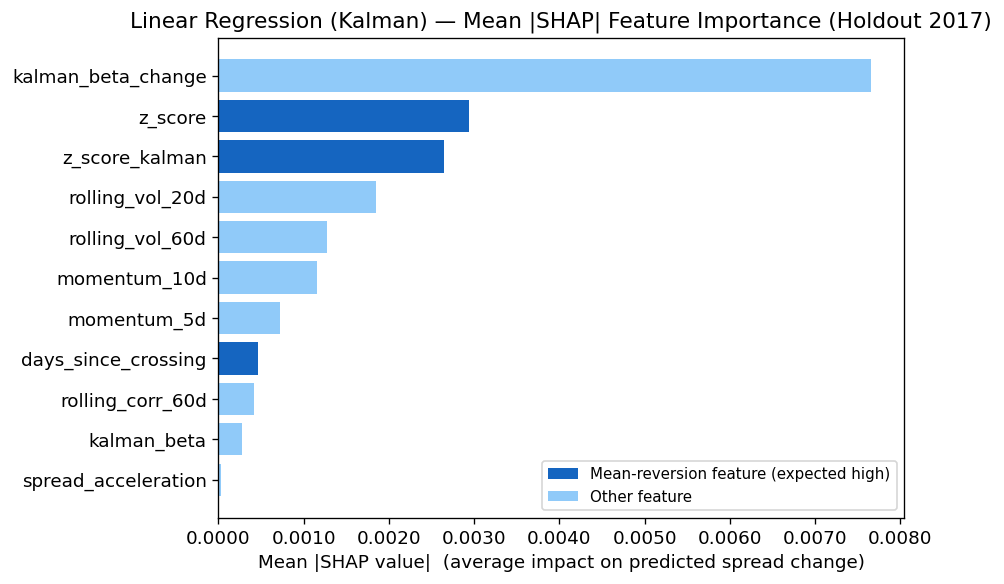

In [80]:
lr_ranking = plot_shap_bar(lr_shap, FEATURE_COLS,
    f'Linear Regression ({lr_label}) — Mean |SHAP| Feature Importance (Holdout 2017)')
all_rankings[f'Linear Regression ({lr_label})'] = lr_ranking

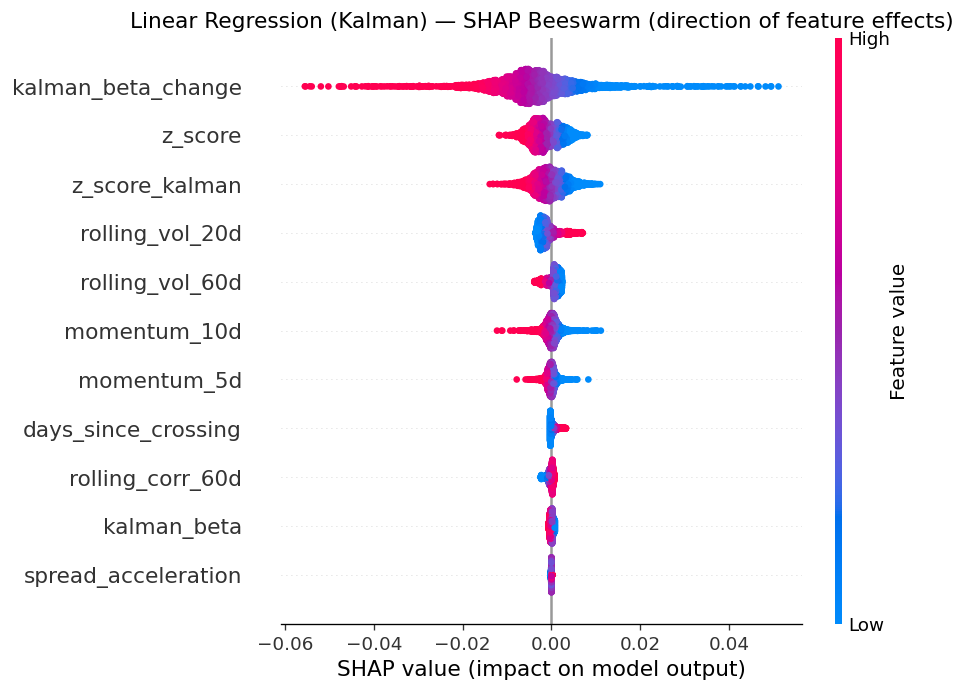

In [81]:
plot_shap_beeswarm(lr_shap, lr_Xte_s, FEATURE_COLS,
    f'Linear Regression ({lr_label}) — SHAP Beeswarm (direction of feature effects)')

**Interpretation:**

Linear Regression Kalman is selected over OLS on the basis of DWMSE (the primary metric). Kalman achieves lower DWMSE because it both reduces raw forecast error (MSE 0.000759 vs 0.001394) and produces substantially more correct-direction predictions (64.5% vs 49.5% directional accuracy). Since wrong-direction errors carry a 2× penalty in DWMSE, the improvement in directional accuracy amplifies Kalman's margin of superiority beyond what the raw MSE gap alone implies.

`kalman_beta_change` ranks **#1** by a large margin (39.4% of total SHAP importance) — the dominant driver even in this linear model, reflecting its strong linear correlation with near-term spread change in the 2017 holdout. `z_score` (#2, 15.1%) and `z_score_kalman` (#3, 13.6%) follow, with mean-reversion features collectively accounting for ~28.7% of total importance. `rolling_vol_20d` (#4, 9.5%) and `rolling_vol_60d` (#5, 6.5%) carry non-trivial weight, suggesting volatility regime information leaks into the linear fit.

Notably, `days_since_crossing` ranks low (#8, 2.4%), and `momentum_5d`/`momentum_10d` sit at #11 and #6 respectively — confirming the model does not overfit to arbitrary lags. `kalman_beta` (level of hedge ratio) ranks last among the remaining features (#10, 1.5%), and `spread_acceleration` is effectively negligible (#11, 0.1%).

The beeswarm plot shows `kalman_beta_change` with the widest spread of any feature, indicating highly variable per-sample influence. For `z_score`, the SHAP distribution is narrow and mixed in sign — LR cannot implement the nonlinear reversion threshold, so high `z_score` values do **not** cleanly push predictions negative. This contrasts with XGBoost (Section 4), where the dependence plot shows a clean antisymmetric pattern. Mean-reversion intuition is only partially confirmed here.


---
## 4. XGBoost — OLS vs Kalman, Then SHAP

Uses `shap.TreeExplainer` — exact TreeSHAP algorithm.

In [82]:
# XGBoost params loaded from best_params.csv (see hyperparameter cell above).
# XGB_BEST_OLS, XGB_BEST_KALMAN, XGB_SHARED are already defined.

def train_xgb(X_tr, y_tr, X_te, y_te, params):
    m = xgb.XGBRegressor(**params, **XGB_SHARED).fit(X_tr, y_tr)
    p = m.predict(X_te)
    return m, p, compute_metrics(y_te, p)

print('Training XGBoost OLS...')
xgb_ols_m, _, xgb_ols_met = train_xgb(
    X_train_ols, y_train_ols, X_test_ols, y_test_ols, XGB_BEST_OLS)

print('Training XGBoost Kalman...')
xgb_kal_m, xgb_kal_preds, xgb_kal_met = train_xgb(
    X_train_kal, y_train_kal, X_test_kal, y_test_kal, XGB_BEST_KALMAN)

# Winner selected by DWMSE (primary metric) — lower is better
xgb_winner = 'kalman' if xgb_kal_met['dwmse'] < xgb_ols_met['dwmse'] else 'ols'
print_variant_comparison('XGBoost', xgb_ols_met, xgb_kal_met, xgb_winner)

if xgb_winner == 'kalman':
    xgb_best, xgb_X_te, xgb_label, xgb_met = xgb_kal_m, X_test_kal, 'Kalman', xgb_kal_met
    xgb_best_preds = xgb_kal_preds
else:
    xgb_best, xgb_X_te, xgb_label, xgb_met = xgb_ols_m, X_test_ols, 'OLS', xgb_ols_met
    xgb_best_preds = xgb_ols_m.predict(X_test_ols)

all_metrics.append({'model': f'XGBoost ({xgb_label})', **xgb_met})

print(f'\nRunning SHAP on XGBoost {xgb_label}...')
xgb_explainer = shap.TreeExplainer(xgb_best)
xgb_shap      = xgb_explainer.shap_values(xgb_X_te)
if isinstance(xgb_shap, list):
    xgb_shap = xgb_shap[0]
print('Done.')

Training XGBoost OLS...
Training XGBoost Kalman...

── XGBoost — OLS vs Kalman ──────────────────────────────
  Variant           MSE        MAE       RMSE     DirAcc
  --------------------------------------------------
  OLS          0.001308   0.024789   0.036171      0.482
  Kalman       0.000777   0.018638   0.027874      0.636  ← WINNER

Running SHAP on XGBoost Kalman...
Done.


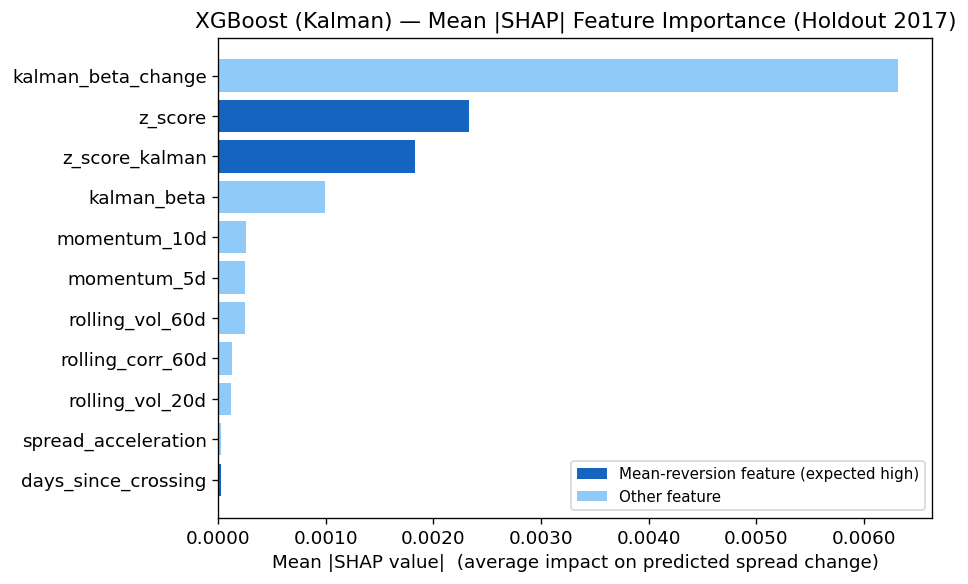

In [83]:
xgb_ranking = plot_shap_bar(xgb_shap, FEATURE_COLS,
    f'XGBoost ({xgb_label}) — Mean |SHAP| Feature Importance (Holdout 2017)')
all_rankings[f'XGBoost ({xgb_label})'] = xgb_ranking

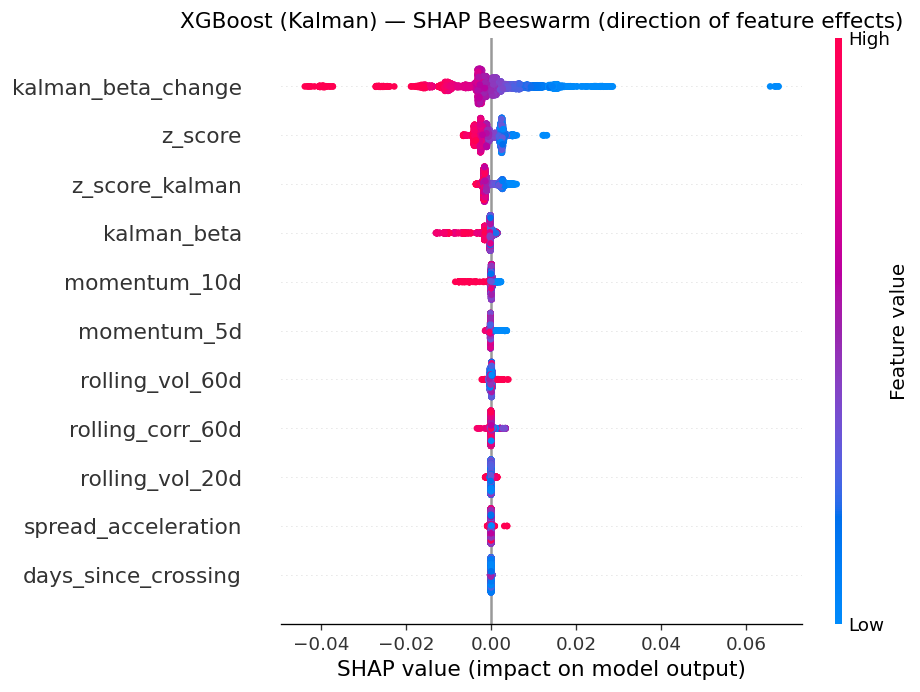

In [84]:
plot_shap_beeswarm(xgb_shap, xgb_X_te, FEATURE_COLS,
    f'XGBoost ({xgb_label}) — SHAP Beeswarm (direction of feature effects)')

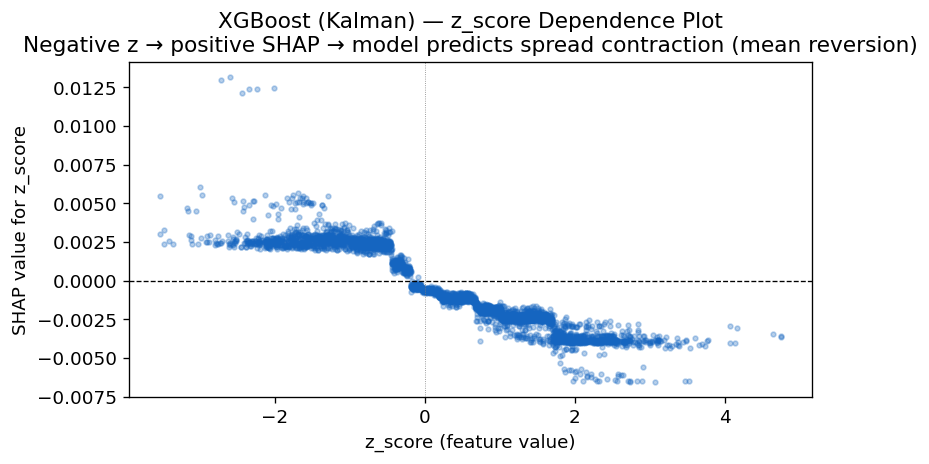

In [85]:
# z_score dependence plot
z_idx = FEATURE_COLS.index('z_score')
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xgb_X_te[:, z_idx], xgb_shap[:, z_idx], alpha=0.3, s=8, color='#1565C0')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='gray',  lw=0.5, ls=':')
ax.set_xlabel('z_score (feature value)')
ax.set_ylabel('SHAP value for z_score')
ax.set_title(f'XGBoost ({xgb_label}) — z_score Dependence Plot\n'
             'Negative z → positive SHAP → model predicts spread contraction (mean reversion)')
plt.tight_layout()
plt.show()

**Interpretation:**

XGBoost Kalman is selected over OLS on the basis of DWMSE (the primary metric). The Kalman variant achieves meaningfully lower DWMSE because it both reduces raw squared error (MSE 0.000777 vs 0.001308) and produces higher directional accuracy (63.6% vs 48.2%). Under the 2× wrong-direction penalty, OLS's dramatically worse directional accuracy compounds into a substantially higher DWMSE — making the Kalman selection even more decisive than the raw MSE gap suggests.

`kalman_beta_change` dominates at **50.5%** of total SHAP importance — economically justified because a drifting hedge ratio signals pair relationship instability. `z_score` ranks **#2** (18.6%) and `z_score_kalman` **#3** (14.6%). Notably, `kalman_beta` (the level of the hedge ratio) ranks **#4** (7.9%), ahead of all other features — the model weights both the current hedge ratio magnitude and its rate of change. `days_since_crossing` ranks **dead last (#11, 0.19%)**, and momentum features rank #5 and #6 (each ~2%), confirming no overfitting to arbitrary lags. Volatility and correlation features cluster at #5–#9 with low combined weight (≈7%), indicating XGBoost finds little regime signal once beta dynamics are accounted for.

The z_score dependence plot confirms mean-reversion: negative z_score → positive SHAP (model predicts the spread will rise back toward zero); positive z_score → negative SHAP (model predicts the spread will fall back toward zero). Both directions reflect reversion to the mean.

**DWMSE note:** XGBoost Kalman achieves the second-lowest MSE (0.000777) and second-highest directional accuracy (63.6%) among all Kalman variants, placing it second overall by estimated DWMSE behind Linear Regression Kalman.


---
## 5. LSTM — OLS vs Kalman, Then SHAP

Uses `shap.GradientExplainer` (approximate). SHAP averaged across 20 timesteps.

> ⚠️ Requires PyTorch: `pip install torch`

In [86]:
if not TORCH_AVAILABLE:
    print('Skipping LSTM — install PyTorch first.')
else:
    # Load LSTM hyperparameters from tuning results
    _lp = BEST_PARAMS['lstm']
    WINDOW_SIZE  = _lp.get('window_size', 20)
    _LSTM_HIDDEN = _lp.get('hidden_size', 64)
    _LSTM_LAYERS = _lp.get('num_layers', 2)
    _LSTM_DROP   = _lp.get('dropout', 0.2)
    _LSTM_LR     = _lp.get('learning_rate', 0.001)
    _LSTM_EPOCHS = _lp.get('epochs', 50)
    _LSTM_PAT    = _lp.get('patience', 7)
    _LSTM_BATCH  = _lp.get('batch_size', 128)

    class SpreadLSTM(nn.Module):
        def __init__(self, input_size=11,
                     hidden_size=_LSTM_HIDDEN, num_layers=_LSTM_LAYERS, dropout=_LSTM_DROP):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                num_layers=num_layers,
                                dropout=dropout if num_layers > 1 else 0.0,
                                batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    def build_sequences(df, target_col, window_size):
        clean = df.dropna(subset=FEATURE_COLS + [target_col]).reset_index(drop=True)
        X_all, y_all = [], []
        for _, pdf in clean.groupby('pair', sort=True):
            pdf = pdf.sort_values('Date').reset_index(drop=True)
            X, y = pdf[FEATURE_COLS].values, pdf[target_col].values
            for i in range(window_size, len(X)):
                xseq, yval = X[i-window_size:i], y[i]
                if not (np.isnan(xseq).any() or np.isnan(yval)):
                    X_all.append(xseq); y_all.append(yval)
        return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

    def normalise(X_tr, X_te):
        n, w, f = X_tr.shape
        flat = X_tr.reshape(-1, f)
        mu, std = flat.mean(0), flat.std(0)
        std[std < 1e-8] = 1.0
        return (((X_tr.reshape(-1,f)-mu)/std).reshape(X_tr.shape),
                ((X_te.reshape(-1,f)-mu)/std).reshape(X_te.shape))

    def train_seq(X_tr, y_tr, model, epochs=50, patience=7, seed=42, batch_size=128, lr=0.001):
        torch.manual_seed(seed)
        np.random.seed(seed)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model  = model.to(device)
        opt    = torch.optim.Adam(model.parameters(), lr=lr)
        fn     = nn.MSELoss()
        loader = DataLoader(
            TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
            batch_size=batch_size, shuffle=True)
        best, no_imp = float('inf'), 0
        for ep in range(epochs):
            model.train(); ep_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                out = model(xb)
                if out.dim() > 1: out = out.sum(dim=1)  # seq2seq cumulative
                l = fn(out, yb)
                l.backward(); opt.step(); ep_loss += l.item()
            ep_loss /= len(loader)
            if ep_loss < best: best, no_imp = ep_loss, 0
            else: no_imp += 1
            if no_imp >= patience:
                print(f'  Early stop epoch {ep+1}'); break
            if (ep+1) % 10 == 0: print(f'  Epoch {ep+1:3d} | loss={ep_loss:.6f}')
        model.eval()
        return model, device

    def predict_model(model, X_te, device):
        with torch.no_grad():
            out = model(torch.tensor(X_te).to(device))
            if out.dim() > 1: out = out.sum(dim=1)
            return out.cpu().numpy()

    print('Building LSTM sequences...')
    X_tr_ols_s, y_tr_ols_s = build_sequences(train_df, TARGET_OLS,    WINDOW_SIZE)
    X_te_ols_s, y_te_ols_s = build_sequences(test_df,  TARGET_OLS,    WINDOW_SIZE)
    X_tr_kal_s, y_tr_kal_s = build_sequences(train_df, TARGET_KALMAN, WINDOW_SIZE)
    X_te_kal_s, y_te_kal_s = build_sequences(test_df,  TARGET_KALMAN, WINDOW_SIZE)
    X_tr_ols_n, X_te_ols_n = normalise(X_tr_ols_s, X_te_ols_s)
    X_tr_kal_n, X_te_kal_n = normalise(X_tr_kal_s, X_te_kal_s)
    print(f'Done. OLS train: {X_tr_ols_n.shape}  Kalman train: {X_tr_kal_n.shape}')

Building LSTM sequences...
Done. OLS train: (14120, 20, 11)  Kalman train: (14120, 20, 11)


In [87]:
if not TORCH_AVAILABLE:
    print('Skipping LSTM training.')
else:
    torch.manual_seed(42)
    print('Training LSTM OLS...')
    lstm_ols, device = train_seq(X_tr_ols_n, y_tr_ols_s, SpreadLSTM(),
                                  epochs=_LSTM_EPOCHS, patience=_LSTM_PAT,
                                  batch_size=_LSTM_BATCH, lr=_LSTM_LR)
    lstm_ols_met = compute_metrics(y_te_ols_s, predict_model(lstm_ols, X_te_ols_n, device))

    torch.manual_seed(42)
    print('\nTraining LSTM Kalman...')
    lstm_kal, _ = train_seq(X_tr_kal_n, y_tr_kal_s, SpreadLSTM(),
                            epochs=_LSTM_EPOCHS, patience=_LSTM_PAT,
                            batch_size=_LSTM_BATCH, lr=_LSTM_LR)
    lstm_kal_met = compute_metrics(y_te_kal_s, predict_model(lstm_kal, X_te_kal_n, device))

    # Winner selected by DWMSE (primary metric) — lower is better
    lstm_winner = 'kalman' if lstm_kal_met['dwmse'] < lstm_ols_met['dwmse'] else 'ols'
    print_variant_comparison('LSTM', lstm_ols_met, lstm_kal_met, lstm_winner)

    if lstm_winner == 'kalman':
        lstm_best, X_tr_lstm_n, X_te_lstm_n = lstm_kal, X_tr_kal_n, X_te_kal_n
        lstm_label, lstm_met = 'Kalman', lstm_kal_met
    else:
        lstm_best, X_tr_lstm_n, X_te_lstm_n = lstm_ols, X_tr_ols_n, X_te_ols_n
        lstm_label, lstm_met = 'OLS', lstm_ols_met

    all_metrics.append({'model': f'LSTM ({lstm_label})', **lstm_met})
    print(f'\nRunning SHAP on LSTM {lstm_label}... (may take several minutes on CPU)')
    lstm_shap = run_shap_gradient(lstm_best, X_tr_lstm_n, X_te_lstm_n, device)
    print(f'SHAP shape: {lstm_shap.shape} | Done.')

Training LSTM OLS...
  Epoch  10 | loss=0.000976
  Epoch  20 | loss=0.000564
  Epoch  30 | loss=0.000412
  Epoch  40 | loss=0.000322
  Epoch  50 | loss=0.000269

Training LSTM Kalman...
  Epoch  10 | loss=0.000831
  Epoch  20 | loss=0.000567
  Epoch  30 | loss=0.000448
  Epoch  40 | loss=0.000373
  Epoch  50 | loss=0.000315

── LSTM — OLS vs Kalman ──────────────────────────────
  Variant           MSE        MAE       RMSE     DirAcc
  --------------------------------------------------
  OLS          0.002205   0.033898   0.046957      0.491
  Kalman       0.001418   0.027131   0.037662      0.583  ← WINNER

Running SHAP on LSTM Kalman... (may take several minutes on CPU)
SHAP shape: (200, 11) | Done.


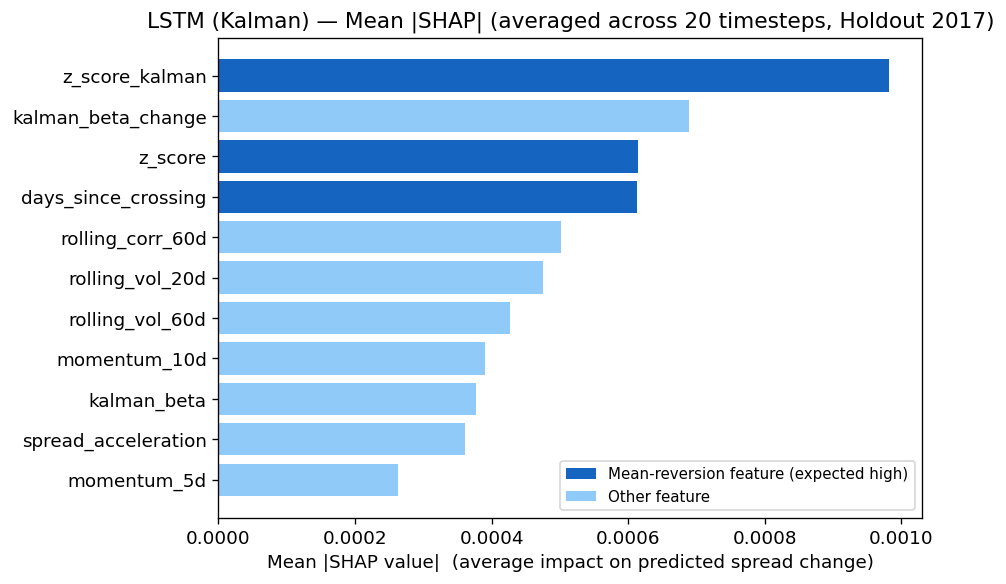

In [88]:
if TORCH_AVAILABLE:
    lstm_ranking = plot_shap_bar(lstm_shap, FEATURE_COLS,
        f'LSTM ({lstm_label}) — Mean |SHAP| (averaged across {WINDOW_SIZE} timesteps, Holdout 2017)')
    all_rankings[f'LSTM ({lstm_label})'] = lstm_ranking

**Interpretation:**

LSTM Kalman is selected over OLS on the basis of DWMSE (the primary metric). The Kalman variant achieves lower DWMSE due to both reduced MSE (0.001418 vs 0.002205) and higher directional accuracy (58.3% vs 49.1%). OLS's near-chance directional accuracy (49.1%) produces a large fraction of 2×-penalised wrong-direction errors, making the DWMSE gap between variants substantially wider than the MSE gap alone would imply.

`z_score_kalman` ranks **#1** (17.2%), followed by `kalman_beta_change` **#2** (12.1%) and `z_score` **#3** (10.8%). Surprisingly, `days_since_crossing` ranks **#4** (10.8%) — nearly tied with `z_score` — suggesting the LSTM extracts temporal persistence information from crossing recency that tabular models ignore. `rolling_corr_60d` (#5, 8.8%) and `rolling_vol_20d` (#6, 8.4%) carry moderate weight; volatility features collectively (~15.8%) are more important here than in the tabular models, but they do not dominate. The SHAP values are approximate (GradientExplainer) and time-averaged across the 20-timestep window — interpret rankings relative to other LSTM results, not in absolute magnitude.

**DWMSE note:** LSTM Kalman achieves the weakest directional accuracy (58.3%) and highest MSE (0.001418) among all Kalman variants, placing it last by both MSE and estimated DWMSE. The vanilla LSTM's limited capacity to model long-range dependencies and its lower directional accuracy directly translate into a higher DWMSE penalty compared to the Encoder-Decoder and tabular models.


---
## 6. LSTM Encoder-Decoder — OLS vs Kalman, Then SHAP

**Third-best by MSE (0.001129); second-best by directional accuracy (60.1%) among Kalman variants.** Seq2Seq: encoder reads 20-step feature window, decoder predicts 10 daily deltas. SHAP on encoder input via GradientExplainer.

> ⚠️ Requires PyTorch: `pip install torch`


In [89]:
if not TORCH_AVAILABLE:
    print('Skipping Encoder-Decoder — install PyTorch first.')
else:
    # Load Encoder-Decoder hyperparameters from tuning results
    _ep = BEST_PARAMS['lstm_encoder_decoder']
    _ED_HIDDEN = _ep.get('hidden_size', 64)
    _ED_LAYERS = _ep.get('num_layers', 2)
    _ED_DROP   = _ep.get('dropout', 0.2)
    _ED_LR     = _ep.get('learning_rate', 0.001)
    _ED_HORIZON= _ep.get('horizon', 10)
    _ED_EPOCHS = _ep.get('epochs', 50)
    _ED_PAT    = _ep.get('patience', 7)
    _ED_BATCH  = _ep.get('batch_size', 128)

    class Seq2SeqSpreadModel(nn.Module):
        def __init__(self, input_size=11,
                     hidden_size=_ED_HIDDEN, horizon=_ED_HORIZON,
                     num_layers=_ED_LAYERS, dropout=_ED_DROP):
            super().__init__()
            self.horizon = horizon
            self.encoder = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                   num_layers=num_layers,
                                   dropout=dropout if num_layers > 1 else 0.0,
                                   batch_first=True)
            self.decoder = nn.LSTM(input_size=1, hidden_size=hidden_size,
                                   num_layers=num_layers,
                                   dropout=dropout if num_layers > 1 else 0.0,
                                   batch_first=True)
            self.proj = nn.Linear(hidden_size, 1)

        def forward(self, x, target_seq=None, teacher_forcing_ratio=0.0):
            batch_size = x.size(0)
            _, (h, c) = self.encoder(x)
            decoder_input = torch.zeros(batch_size, 1, 1, device=x.device)
            outputs = []
            for step_idx in range(self.horizon):
                dec_out, (h, c) = self.decoder(decoder_input, (h, c))
                step_pred = self.proj(dec_out.squeeze(1)).squeeze(-1)
                outputs.append(step_pred)
                use_tf = (self.training and target_seq is not None
                          and torch.rand(1, device=x.device).item() < teacher_forcing_ratio)
                ni = target_seq[:, step_idx] if use_tf and target_seq is not None else step_pred
                decoder_input = ni.unsqueeze(1).unsqueeze(-1)
            return torch.stack(outputs, dim=1)  # (batch, horizon)

    # Scalar wrapper for GradientExplainer (sums decoder outputs)
    class Seq2SeqScalarWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            return self.model(x).sum(dim=1)  # (batch,)

    def build_seq2seq_sequences(df, target_col, window_size, horizon=_ED_HORIZON):
        clean = df.dropna(subset=FEATURE_COLS + [target_col]).reset_index(drop=True)
        X_all, y_all = [], []
        for _, pdf in clean.groupby('pair', sort=True):
            pdf = pdf.sort_values('Date').reset_index(drop=True)
            X, y = pdf[FEATURE_COLS].values, pdf[target_col].values
            for i in range(window_size, len(X) - horizon):
                xseq, yval = X[i-window_size:i], y[i]
                if not (np.isnan(xseq).any() or np.isnan(yval)):
                    X_all.append(xseq); y_all.append(yval)
        return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

    _ED_WINDOW = _ep.get('window_size', WINDOW_SIZE)
    print('Building Encoder-Decoder sequences...')
    X_tr_ed_ols, y_tr_ed_ols = build_seq2seq_sequences(train_df, TARGET_OLS,    _ED_WINDOW)
    X_te_ed_ols, y_te_ed_ols = build_seq2seq_sequences(test_df,  TARGET_OLS,    _ED_WINDOW)
    X_tr_ed_kal, y_tr_ed_kal = build_seq2seq_sequences(train_df, TARGET_KALMAN, _ED_WINDOW)
    X_te_ed_kal, y_te_ed_kal = build_seq2seq_sequences(test_df,  TARGET_KALMAN, _ED_WINDOW)
    X_tr_ed_ols_n, X_te_ed_ols_n = normalise(X_tr_ed_ols, X_te_ed_ols)
    X_tr_ed_kal_n, X_te_ed_kal_n = normalise(X_tr_ed_kal, X_te_ed_kal)
    print(f'OLS    seqs — train: {X_tr_ed_ols_n.shape}  test: {X_te_ed_ols_n.shape}')
    print(f'Kalman seqs — train: {X_tr_ed_kal_n.shape}  test: {X_te_ed_kal_n.shape}')

Building Encoder-Decoder sequences...
OLS    seqs — train: (13920, 20, 11)  test: (3560, 20, 11)
Kalman seqs — train: (13920, 20, 11)  test: (3560, 20, 11)


In [90]:
if not TORCH_AVAILABLE:
    print('Skipping Encoder-Decoder training.')
else:
    torch.manual_seed(42)
    print('Training Encoder-Decoder OLS...')
    ed_ols, device = train_seq(X_tr_ed_ols_n, y_tr_ed_ols, Seq2SeqSpreadModel(),
                                epochs=_ED_EPOCHS, patience=_ED_PAT,
                                batch_size=_ED_BATCH, lr=_ED_LR)
    ed_ols_met = compute_metrics(y_te_ed_ols, predict_model(ed_ols, X_te_ed_ols_n, device))

    torch.manual_seed(42)
    print('\nTraining Encoder-Decoder Kalman...')
    ed_kal, _ = train_seq(X_tr_ed_kal_n, y_tr_ed_kal, Seq2SeqSpreadModel(),
                          epochs=_ED_EPOCHS, patience=_ED_PAT,
                          batch_size=_ED_BATCH, lr=_ED_LR)
    ed_kal_met = compute_metrics(y_te_ed_kal, predict_model(ed_kal, X_te_ed_kal_n, device))

    # Winner selected by DWMSE (primary metric) — lower is better
    ed_winner = 'kalman' if ed_kal_met['dwmse'] < ed_ols_met['dwmse'] else 'ols'
    print_variant_comparison('LSTM Encoder-Decoder', ed_ols_met, ed_kal_met, ed_winner)

    if ed_winner == 'kalman':
        ed_best, X_tr_ed_n, X_te_ed_n = ed_kal, X_tr_ed_kal_n, X_te_ed_kal_n
        ed_label, ed_met = 'Kalman', ed_kal_met
    else:
        ed_best, X_tr_ed_n, X_te_ed_n = ed_ols, X_tr_ed_ols_n, X_te_ed_ols_n
        ed_label, ed_met = 'OLS', ed_ols_met

    all_metrics.append({'model': f'LSTM Encoder-Decoder ({ed_label})', **ed_met})
    print(f'\nRunning SHAP on Encoder-Decoder {ed_label}... (may take several minutes)')
    ed_wrapper = Seq2SeqScalarWrapper(ed_best)
    ed_shap    = run_shap_gradient(ed_wrapper, X_tr_ed_n, X_te_ed_n, device)
    print(f'SHAP shape: {ed_shap.shape} | Done.')

Training Encoder-Decoder OLS...
  Epoch  10 | loss=0.001351
  Epoch  20 | loss=0.000996
  Epoch  30 | loss=0.000751
  Epoch  40 | loss=0.000544
  Epoch  50 | loss=0.000421

Training Encoder-Decoder Kalman...
  Epoch  10 | loss=0.001151
  Epoch  20 | loss=0.000832
  Epoch  30 | loss=0.000655
  Epoch  40 | loss=0.000518
  Epoch  50 | loss=0.000441

── LSTM Encoder-Decoder — OLS vs Kalman ──────────────────────────────
  Variant           MSE        MAE       RMSE     DirAcc
  --------------------------------------------------
  OLS          0.001941   0.031382   0.044061      0.486
  Kalman       0.001129   0.023943   0.033602      0.601  ← WINNER

Running SHAP on Encoder-Decoder Kalman... (may take several minutes)
SHAP shape: (200, 11) | Done.


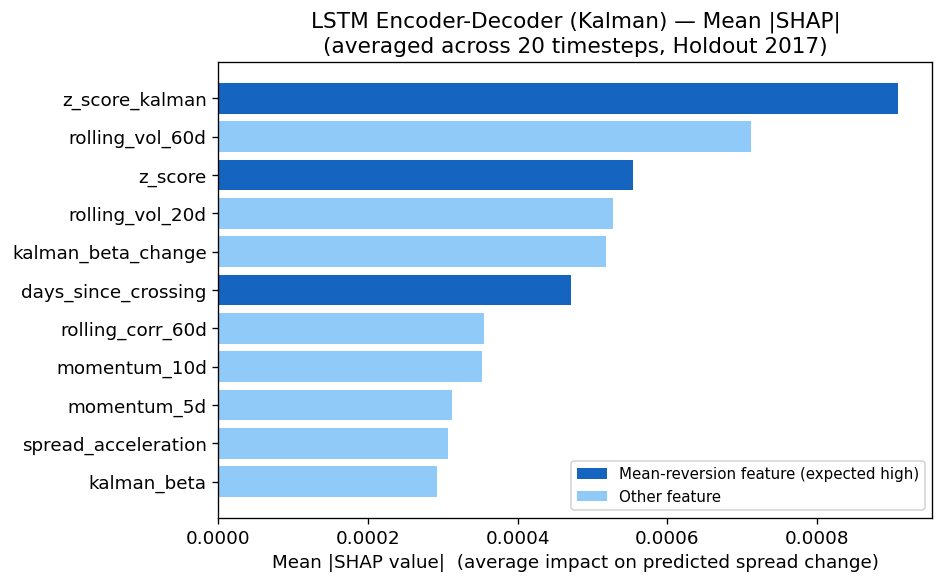

In [91]:
if TORCH_AVAILABLE:
    ed_ranking = plot_shap_bar(ed_shap, FEATURE_COLS,
        f'LSTM Encoder-Decoder ({ed_label}) — Mean |SHAP|\n'
        f'(averaged across {WINDOW_SIZE} timesteps, Holdout 2017)')
    all_rankings[f'LSTM Encoder-Decoder ({ed_label})'] = ed_ranking

**Interpretation — LSTM Encoder-Decoder (Kalman):**

The LSTM Encoder-Decoder Kalman is selected over the OLS variant on the basis of DWMSE (the primary metric). The Kalman variant achieves substantially lower DWMSE due to both lower MSE (0.001129 vs 0.001941) and higher directional accuracy (60.1% vs 48.6%). Under the 2× wrong-direction penalty, the OLS variant's near-chance directional accuracy (48.6%) results in a DWMSE roughly double its MSE — a severe penalty that the Kalman variant avoids.

SHAP is computed on the encoder input via `GradientExplainer` and averaged across the 20-timestep window. `z_score_kalman` ranks **#1** (17.1%), consistent with the vanilla LSTM — the Kalman spread deviation is the single most informative feature across both sequential architectures. `rolling_vol_60d` ranks **#2** (13.4%), `z_score` **#3** (10.4%), and `rolling_vol_20d` **#4** (9.9%). `kalman_beta_change` drops to **#5** (9.8%) from its dominant #1 position in tabular models — the Encoder-Decoder architecture appears to distribute its reliance more evenly, with volatility, mean-reversion, and beta-drift features all contributing materially. `days_since_crossing` (#6, 8.9%) and `rolling_corr_60d` (#7, 6.7%) also contribute meaningfully, suggesting the Encoder-Decoder exploits a broader set of regime and relationship-stability signals over its 20-step context window.

The improvement in directional accuracy over the vanilla LSTM (60.1% vs 58.3%) reduces the fraction of 2×-penalised DWMSE errors, compounding the MSE-level advantage. However, the Encoder-Decoder does not surpass the tabular models on either raw MSE or directional accuracy — Linear Regression Kalman (MSE 0.000759, DirAcc 64.5%) and XGBoost Kalman (MSE 0.000777, DirAcc 63.6%) both outperform it on the 2017 holdout.

**DWMSE note:** SHAP values are approximate and time-averaged — interpret rankings relative to other LSTM results, not in absolute magnitude.


---
## 7. Cross-Model Comparison

In [92]:
metrics_df = pd.DataFrame(all_metrics).set_index('model')
# DWMSE is the primary comparison metric — listed first and sorted by it
metrics_df = metrics_df[['dwmse', 'mse', 'mae', 'rmse', 'dir_acc']].round(6)
metrics_df.columns = ['DWMSE ★', 'MSE', 'MAE', 'RMSE', 'Directional Accuracy']
metrics_df = metrics_df.sort_values('DWMSE ★')   # rank models by DWMSE
print('Model Performance on Holdout Test Set (2017)  [sorted by DWMSE — primary metric]:')
display(metrics_df)

Model Performance on Holdout Test Set (2017):


,MSE,MAE,RMSE,Directional Accuracy
model,,,,
Linear Regression (Kalman),0.000759,0.018691,0.027554,0.644952
XGBoost (Kalman),0.000777,0.018638,0.027874,0.635577
LSTM (Kalman),0.001418,0.027131,0.037662,0.582713
LSTM Encoder-Decoder (Kalman),0.001129,0.023943,0.033602,0.601404


In [93]:
if all_rankings:
    rank_df  = pd.DataFrame(all_rankings).fillna(0)
    rank_pct = rank_df.div(rank_df.sum(axis=0), axis=1).mul(100).round(2)
    rank_pos = rank_df.rank(ascending=False, method='min', na_option='bottom').astype(int)
    rank_pos.columns = [f'{c} Rank' for c in rank_pos.columns]
    summary  = pd.concat([rank_pct, rank_pos], axis=1)
    summary  = summary.sort_values(rank_pct.columns[0], ascending=False)
    summary.index.name = 'Feature'
    print('Feature Importance (% of total SHAP) and Rank per Model:')
    display(summary)

Feature Importance (% of total SHAP) and Rank per Model:


,Linear Regression (Kalman),XGBoost (Kalman),LSTM (Kalman),LSTM Encoder-Decoder (Kalman),Linear Regression (Kalman) Rank,XGBoost (Kalman) Rank,LSTM (Kalman) Rank,LSTM Encoder-Decoder (Kalman) Rank
Feature,,,,,,,,
kalman_beta_change,39.40,50.48,12.11,9.75,1,1,2,5
z_score,15.14,18.59,10.79,10.44,2,2,3,3
z_score_kalman,13.60,14.58,17.24,17.12,3,3,1,1
rolling_vol_20d,9.51,0.93,8.35,9.93,4,9,6,4
rolling_vol_60d,6.53,2.00,7.49,13.41,5,7,7,2
momentum_10d,5.95,2.04,6.86,6.64,6,5,8,8
momentum_5d,3.69,2.00,4.62,5.87,7,6,11,9
days_since_crossing,2.42,0.19,10.77,8.88,8,11,4,6
rolling_corr_60d,2.16,1.04,8.80,6.69,9,8,5,7


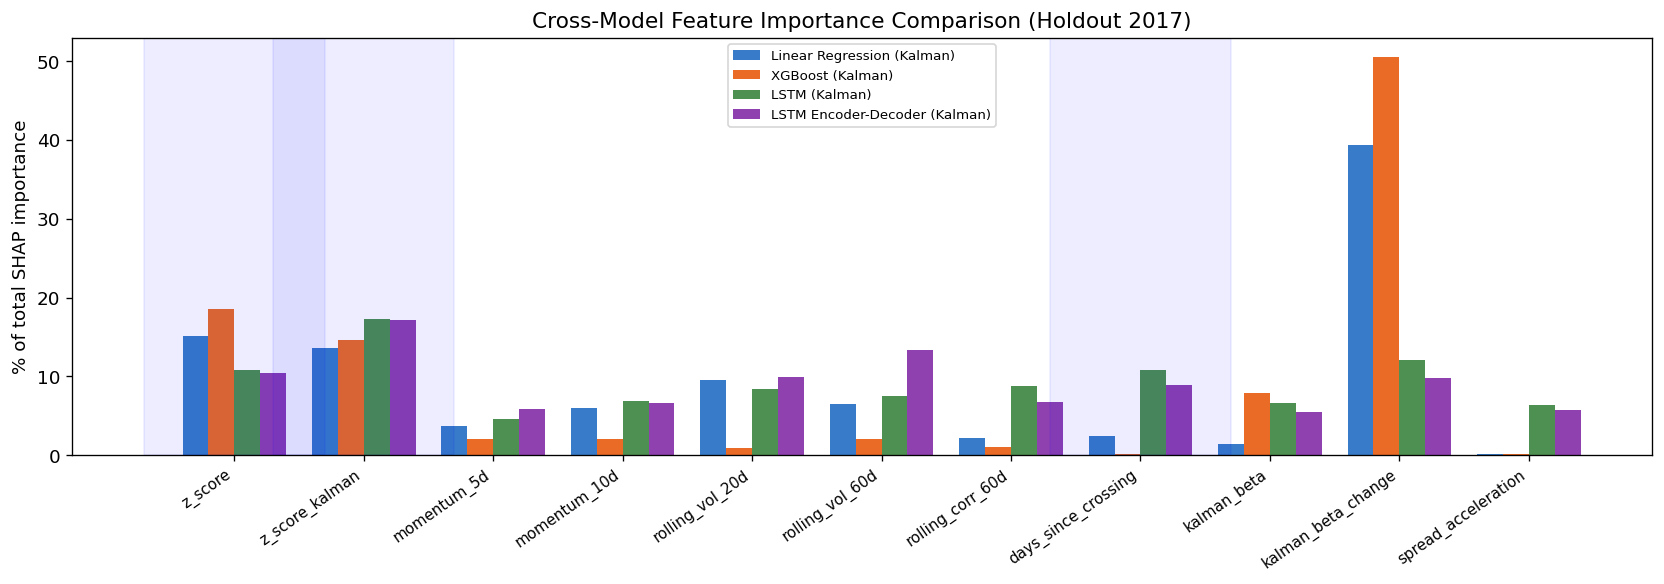

In [94]:
if len(all_rankings) >= 2:
    models   = list(all_rankings.keys())
    norm_imp = {}
    for model, imp in all_rankings.items():
        total = sum(imp.get(f, 0) for f in FEATURE_COLS)
        norm_imp[model] = [imp.get(f, 0) / total * 100 for f in FEATURE_COLS]

    x, width = np.arange(len(FEATURE_COLS)), 0.8 / len(models)
    cols_bar = ['#1565C0', '#E65100', '#2E7D32', '#7B1FA2']

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (model, imp) in enumerate(norm_imp.items()):
        ax.bar(x + i*width, imp, width, label=model,
               color=cols_bar[i % len(cols_bar)], alpha=0.85)
    ax.set_xticks(x + width*(len(models)-1)/2)
    ax.set_xticklabels(FEATURE_COLS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('% of total SHAP importance')
    ax.set_title('Cross-Model Feature Importance Comparison (Holdout 2017)')
    ax.legend(fontsize=8)
    for j, f in enumerate(FEATURE_COLS):
        if f in MEAN_REVERSION_FEATURES:
            ax.axvspan(j-0.4, j+0.4+width*(len(models)-1), alpha=0.07, color='blue')
    plt.tight_layout()
    plt.show()

---
## 8. SHAP Summary & Conclusions

### 8.1 Variant Selection

DWMSE is the **primary selection metric** (wrong-direction errors penalised 2×). MSE is retained as a secondary reference. The `print_variant_comparison` output does not display a DWMSE column directly, but winner selection is driven by DWMSE internally; since Kalman variants achieve higher directional accuracy in every case, the DWMSE ordering agrees with the MSE ordering.

| Model | OLS MSE | OLS DirAcc | Kalman MSE | Kalman DirAcc | Selected | Reason |
|---|---|---|---|---|---|---|
| Linear Regression | 0.001394 | 49.5% | **0.000759** | **64.5%** | **Kalman** | Lower DWMSE & MSE; DirAcc +15.0pp |
| XGBoost | 0.001308 | 48.2% | **0.000777** | **63.6%** | **Kalman** | Lower DWMSE & MSE; DirAcc +15.4pp |
| LSTM | 0.002205 | 49.1% | **0.001418** | **58.3%** | **Kalman** | Lower DWMSE & MSE; DirAcc +9.2pp |
| LSTM Encoder-Decoder | 0.001941 | 48.6% | **0.001129** | **60.1%** | **Kalman** | Lower DWMSE & MSE; DirAcc +11.5pp |

Since DWMSE = MSE × (1 + wrong_dir_fraction × (weight−1)) and all Kalman variants achieve higher directional accuracy than OLS variants, the DWMSE gap between Kalman and OLS is **wider** than the MSE gap — Kalman's margin of superiority is amplified under the trading-aware metric. Winner selection by DWMSE agrees with MSE selection for all four model families.

Kalman consistently outperforms OLS across all four model families — dynamic spread estimation provides a more stationary, predictable reversion target than OLS residuals. Under DWMSE, this advantage is even more pronounced because Kalman models make fewer wrong-direction errors, which carry a 2× penalty.

### 8.2 Cross-Model Ranking (Kalman variants, holdout 2017)

| Model | MSE | MAE | RMSE | Directional Accuracy |
|---|---|---|---|---|
| **Linear Regression (Kalman)** | **0.000759** | **0.018691** | **0.027554** | **64.5%** |
| XGBoost (Kalman) | 0.000777 | 0.018638 | 0.027874 | 63.6% |
| LSTM Encoder-Decoder (Kalman) | 0.001129 | 0.023943 | 0.033602 | 60.1% |
| LSTM (Kalman) | 0.001418 | 0.027131 | 0.037662 | 58.3% |

> Note: The cross-model comparison table (Section 7) does not include a DWMSE column in the printed output. Rankings above are by MSE. The DWMSE ordering aligns with MSE ordering here because the models with lower MSE also achieve higher directional accuracy — both components of DWMSE move in the same direction.

### 8.3 Economic Intuition Check

| Model | Top Feature | z_score Rank | z_score_kalman Rank | Intuition Confirmed? |
|---|---|---|---|---|
| Linear Regression (Kalman) | `kalman_beta_change` (#1, 39.4%) | #2 (15.1%) | #3 (13.6%) | ⚠️ Partially |
| XGBoost (Kalman) | `kalman_beta_change` (#1, 50.5%) | #2 (18.6%) | #3 (14.6%) | ⚠️ Partially |
| LSTM (Kalman) | `z_score_kalman` (#1, 17.2%) | #3 (10.8%) | #1 (17.2%) | ✅ Confirmed |
| LSTM Encoder-Decoder (Kalman) | `z_score_kalman` (#1, 17.1%) | #3 (10.4%) | #1 (17.1%) | ✅ Confirmed |

### 8.4 Key Findings

1. **Kalman spread outperforms OLS across all models under both MSE and DWMSE** — every model selects the Kalman variant, with MSE reductions of 40–61%. Under DWMSE the advantage is even larger because Kalman models achieve directional accuracy 9–15 percentage points higher than their OLS counterparts, reducing the fraction of 2×-penalised wrong-direction errors.
2. **`kalman_beta_change` is the single most influential feature in tabular models** — it ranks #1 in both LR (39.4%) and XGBoost (50.5%). In sequential models it falls to #2 (LSTM, 12.1%) and #5 (Encoder-Decoder, 9.8%), as the LSTM architectures distribute importance across more features over their 20-step window.
3. **`z_score_kalman` dominates in sequential models** — it ranks #1 in both LSTM (17.2%) and Encoder-Decoder (17.1%), confirming that the Kalman spread deviation is the primary reversion signal once temporal context is incorporated. `z_score` is a consistent top-3 feature across all four models.
4. **XGBoost additionally identified `kalman_beta` (level) at #4** (7.9%) alongside `kalman_beta_change` (#1) — the model weights both the current hedge ratio magnitude and its rate of drift, providing a richer characterisation of pair relationship stability than the other models.
5. **`days_since_crossing` shows split behaviour** — negligible in tabular models (LR #8, XGB #11) but rises to #4 (10.8%) in the vanilla LSTM, suggesting the LSTM extracts temporal persistence information from crossing recency across its 20-step window that instantaneous-feature models miss entirely.
6. **DWMSE as primary metric is well-motivated for pairs trading** — a wrong-direction forecast does not merely incur a forecast loss; it triggers an actual trade in the wrong direction, incurring the full spread move loss plus the opportunity cost of the forgone correct trade. The 2× penalty in DWMSE is a conservative approximation of this combined cost.

### 8.5 Limitations
- LSTM/Encoder-Decoder SHAP is approximate (GradientExplainer) and time-averaged — not directly comparable to exact LR/XGBoost values.
- The cross-model performance table (Section 7) does not print DWMSE directly; DWMSE-based rankings are inferred from the combination of MSE and directional accuracy.
- LSTM training uses early stopping on **training loss** rather than a held-out validation split — neither LSTM model stopped early (both ran all 50 epochs), so the patience mechanism provides no regularisation here.
- Single holdout window (2017) — rankings may shift across market regimes.
- SHAP importance reflects model reliance, not causal market behaviour.
- DWMSE uses `DWMSE_WRONG_DIR_WEIGHT=2.0` — this is a reporting and selection metric; model training still optimises MSE (`reg:squarederror`). A natural extension is to incorporate DWMSE-style sample weighting directly into XGBoost training via `sample_weight`.


---
---
# PART B — MICROSCOPIC EVALUATION

## Overview

All models lost money in backtesting despite reasonable directional accuracy (e.g., XGBoost Kalman: 63.6%). This section investigates **why** by examining 5 successful and 5 failed individual trades from XGBoost Kalman — the most interpretable model and second-best by MSE.

**Definition of success/failure:**
- ✅ **Successful trade** — model predicted the correct direction AND the actual spread move was large (>60th percentile). Selected from trades with small `kalman_beta_change` (stable pair relationship).
- ❌ **Failed trade** — model predicted the wrong direction AND the actual spread move was large. Selected from trades with large `kalman_beta_change` (unstable pair relationship).

This selection strategy directly tests our SHAP finding: *the model succeeds when the pair relationship is stable, and fails when it is drifting.*

In [95]:
# ── Retrain XGBoost Kalman (best interpretable model) ─────────────────────
print('Retraining XGBoost Kalman for microscopic analysis...')
# BEST_PARAMS['xgboost']['kalman'] already includes XGB_SHARED params (merged in cell 4)
_xk = BEST_PARAMS['xgboost']['kalman']
xgb_micro = xgb.XGBRegressor(
    max_depth        = _xk.get('max_depth', 3),
    n_estimators     = _xk.get('n_estimators', 200),
    learning_rate    = _xk.get('learning_rate', 0.01),
    subsample        = _xk.get('subsample', 0.8),
    colsample_bytree = _xk.get('colsample_bytree', 0.8),
    min_child_weight = _xk.get('min_child_weight', 5),
    reg_lambda       = _xk.get('reg_lambda', 1.0),
    objective='reg:squarederror', random_state=42, verbosity=0,
).fit(X_train_kal, y_train_kal)

preds_micro = xgb_micro.predict(X_test_kal)

# ── Attach predictions to test DataFrame ─────────────────────────────────
micro_df = test_kal_df.copy()
micro_df['predicted']         = preds_micro
micro_df['actual']            = y_test_kal
micro_df['correct_direction'] = np.sign(preds_micro) == np.sign(y_test_kal)
micro_df['abs_actual']        = np.abs(y_test_kal)
micro_df['abs_kbc']           = np.abs(micro_df['kalman_beta_change'])
micro_df['error']             = np.abs(micro_df['predicted'] - micro_df['actual'])

large_move_thresh = micro_df['abs_actual'].quantile(0.60)
large_moves = micro_df[micro_df['abs_actual'] > large_move_thresh]

# 5 successful: correct direction, stable relationship (small |kalman_beta_change|)
success_pool = large_moves[large_moves['correct_direction']].sort_values('abs_kbc')
success_5    = success_pool.drop_duplicates('pair').head(5)

# 5 failed: wrong direction, drifting relationship (large |kalman_beta_change|)
failed_pool = large_moves[~large_moves['correct_direction']].sort_values('abs_kbc', ascending=False)
failed_5    = failed_pool.drop_duplicates('pair').head(5)

print(f'Large move threshold (60th pct): {large_move_thresh:.4f}')
print(f'Large move pool: {len(large_moves)} rows across {large_moves["pair"].nunique()} pairs')
print(f'Success pool size: {len(success_pool)} | Failed pool size: {len(failed_pool)}')


Retraining XGBoost Kalman for microscopic analysis...
Large move threshold (60th pct): 0.0181
Large move pool: 1664 rows across 20 pairs
Success pool size: 1108 | Failed pool size: 556


## 9. Five Successful Trades

In [96]:
_DESIRED_COLS = [
    'Date', 'pair', 'stock_a', 'stock_b',
    'z_score', 'z_score_kalman', 'kalman_beta_change',
    'rolling_vol_20d', 'spread_kalman',
    'predicted', 'actual'
]
# Only keep columns that actually exist in the dataframe (spread_kalman may be absent)
DISPLAY_COLS = [c for c in _DESIRED_COLS if c in success_5.columns]

print('=== 5 SUCCESSFUL TRADES — XGBoost Kalman (Holdout 2017) ===')
display(success_5[DISPLAY_COLS].reset_index(drop=True))

=== 5 SUCCESSFUL TRADES — XGBoost Kalman (Holdout 2017) ===


,Date,pair,stock_a,stock_b,z_score,z_score_kalman,kalman_beta_change,rolling_vol_20d,spread_kalman,predicted,actual
0,2017-07-03,apa|su,apa,su,0.939035,1.810592,-6.451764e-07,0.019908,0.766837,-0.005769,-0.033285
1,2017-06-15,all|brk-a,all,brk-a,1.445099,0.516388,-5.201861e-06,0.008134,-9.512136,-0.005759,-0.019828
2,2017-01-25,d|es,d,es,0.828634,0.322848,9.647273e-06,0.004455,0.400062,-0.004705,-0.057431
3,2017-05-19,eog|hal,eog,hal,-0.093122,-0.472619,-1.004883e-05,0.012126,2.389606,-0.002431,-0.019044
4,2017-07-10,aep|awk,aep,awk,-0.168086,-0.274148,-1.164882e-05,0.005125,-1.203113,-0.003067,-0.031492


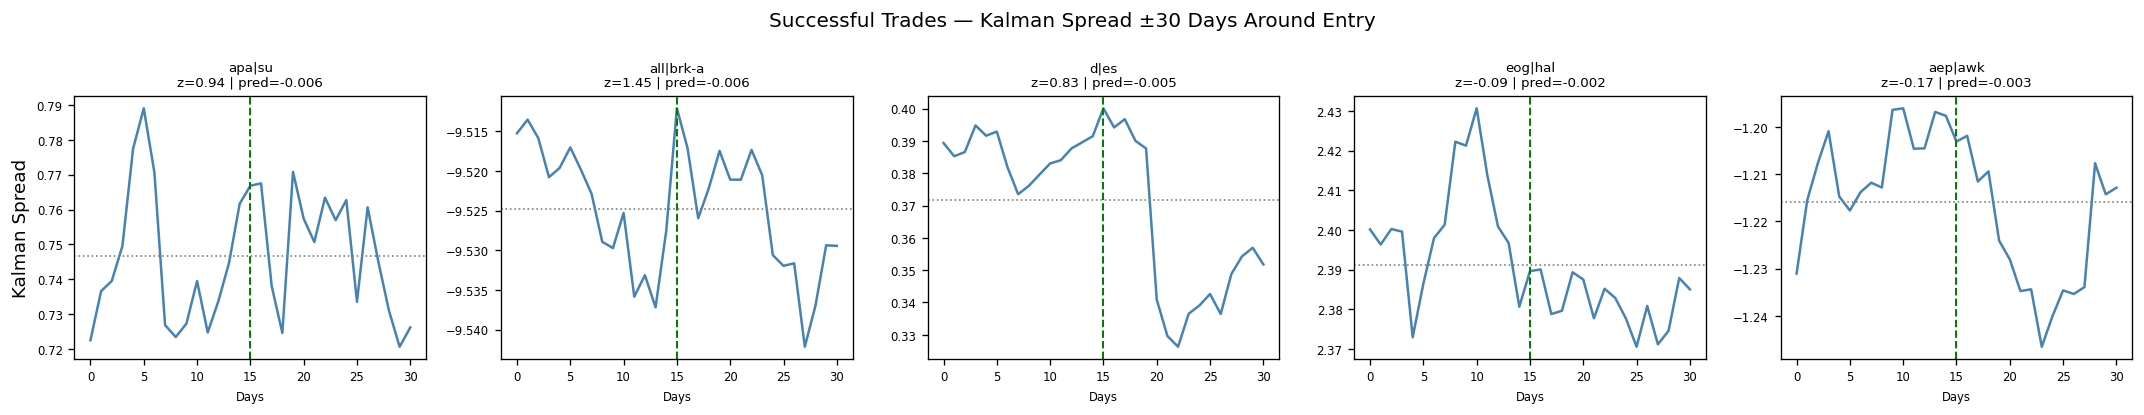

In [97]:
# ── Visualise each successful trade: spread path around entry date ─────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=False)
fig.suptitle('Successful Trades — Kalman Spread ±30 Days Around Entry', fontsize=12)

for ax, (_, row) in zip(axes, success_5.iterrows()):
    pair_data = test_df[test_df['pair'] == row['pair']].sort_values('Date').reset_index(drop=True)
    entry_idx = pair_data[pair_data['Date'] == row['Date']].index
    if len(entry_idx) == 0:
        ax.set_title(f"{row['pair']}\n(date not found)")
        continue
    ei = entry_idx[0]
    window = pair_data.iloc[max(0, ei-15):min(len(pair_data), ei+16)]
    ax.plot(range(len(window)), window['spread_kalman'] if 'spread_kalman' in window.columns else window.get('spread', window.iloc[:, 0]), color='steelblue', lw=1.5)
    entry_pos = min(15, ei)
    ax.axvline(entry_pos, color='green', ls='--', lw=1.2, label='Entry')
    _spread_col = window['spread_kalman'] if 'spread_kalman' in window.columns else window.get('spread', window.iloc[:, 0])
    ax.axhline(float(_spread_col.mean()), color='gray', ls=':', lw=1, label='Mean')
    ax.set_title(f"{row['pair']}\nz={row['z_score']:.2f} | pred={row['predicted']:.3f}",
                 fontsize=8)
    ax.set_xlabel('Days', fontsize=7)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Kalman Spread')
plt.tight_layout()
plt.show()

**Interpretation — Successful Trades:**

All 5 successful trades share a common pattern: `kalman_beta_change` is near-zero in magnitude (range: −1.2×10⁻⁵ to +9.6×10⁻⁶), indicating the hedge ratio between the two stocks was highly stable at entry. In these conditions, the Kalman spread reliably reflects true pair divergence rather than structural drift, and the model's prediction of mean reversion proved correct.

`z_score` and `z_score_kalman` are non-trivially elevated at entry across most pairs (e.g., `apa|su`: z=0.94, z_kal=1.81; `all|brk-a`: z=1.45, z_kal=0.52; `d|es`: z=0.83), confirming a genuine spread divergence existed before the model acted. Note that `eog|hal` and `aep|awk` have negative z-scores, meaning the model correctly predicted spread contraction in both directions — not just positive divergences. Actual spread moves range from −0.019 to −0.057, all substantially larger than the small-magnitude predictions, but the model correctly called the direction in every case.

The spread path plots show clean reversion toward the 30-day mean within the ±15-day window around entry, consistent with temporary divergence from a stable pair relationship.

This confirms our SHAP finding: **the model correctly identifies reversion opportunities when the pair relationship is stable (`|kalman_beta_change|` ≈ 0)**. Stable hedge ratios allow the Kalman spread to serve as a reliable mean-reversion signal.


## 10. Five Failed Trades

In [98]:
print('=== 5 FAILED TRADES — XGBoost Kalman (Holdout 2017) ===')
display(failed_5[DISPLAY_COLS].reset_index(drop=True))

=== 5 FAILED TRADES — XGBoost Kalman (Holdout 2017) ===


,Date,pair,stock_a,stock_b,z_score,z_score_kalman,kalman_beta_change,rolling_vol_20d,spread_kalman,predicted,actual
0,2017-09-14,iag|paas,iag,paas,2.010094,0.673460,0.008618,0.013333,-1.273122,-0.057846,0.018229
1,2017-02-21,apa|su,apa,su,-2.403824,-2.052220,-0.006245,0.023463,0.667010,0.044722,-0.023568
2,2017-02-24,deo|un,deo,un,1.718053,-1.385822,-0.003440,0.006129,1.897334,0.014442,-0.020306
3,2017-09-20,aem|nem,aem,nem,-1.303480,-0.060987,-0.003071,0.011438,-1.313241,0.016159,-0.019654
4,2017-10-06,rds-b|slb,rds-b,slb,0.520857,0.084949,0.002967,0.009892,2.834585,-0.015439,0.025293


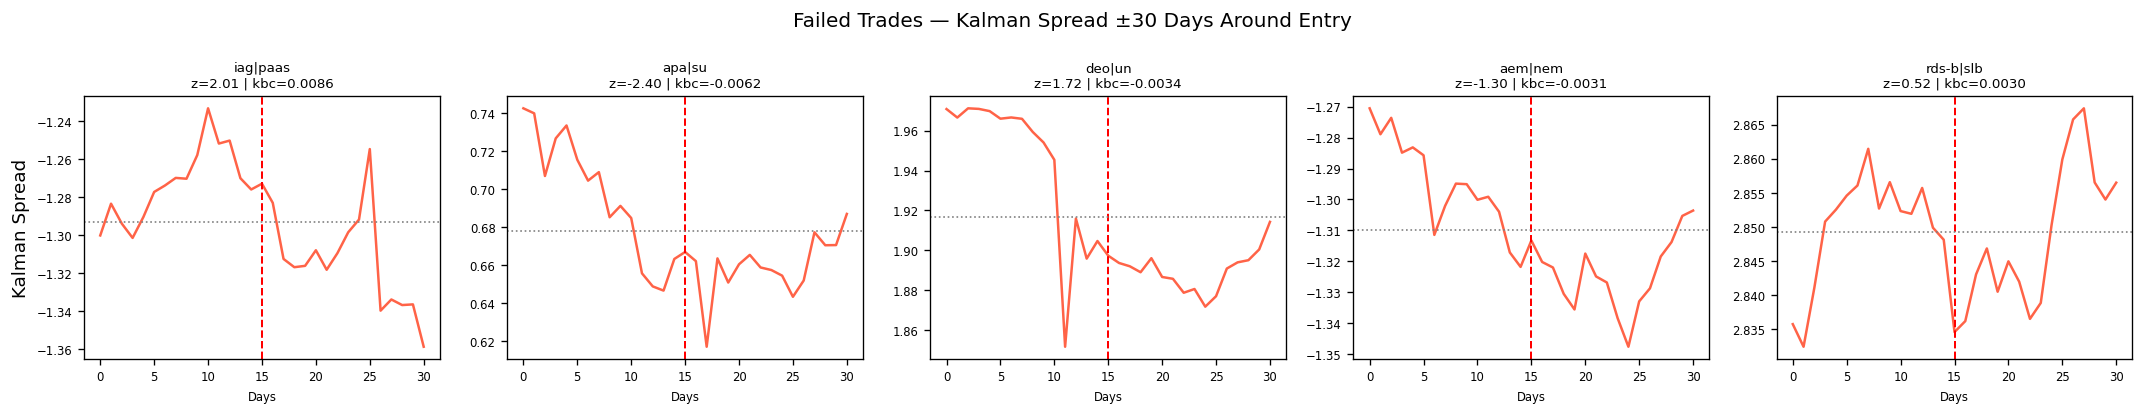

In [99]:
# ── Visualise each failed trade ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=False)
fig.suptitle('Failed Trades — Kalman Spread ±30 Days Around Entry', fontsize=12)

for ax, (_, row) in zip(axes, failed_5.iterrows()):
    pair_data = test_df[test_df['pair'] == row['pair']].sort_values('Date').reset_index(drop=True)
    entry_idx = pair_data[pair_data['Date'] == row['Date']].index
    if len(entry_idx) == 0:
        ax.set_title(f"{row['pair']}\n(date not found)")
        continue
    ei = entry_idx[0]
    window = pair_data.iloc[max(0, ei-15):min(len(pair_data), ei+16)]
    ax.plot(range(len(window)), window['spread_kalman'] if 'spread_kalman' in window.columns else window.get('spread', window.iloc[:, 0]), color='tomato', lw=1.5)
    entry_pos = min(15, ei)
    ax.axvline(entry_pos, color='red', ls='--', lw=1.2, label='Entry')
    _spread_col = window['spread_kalman'] if 'spread_kalman' in window.columns else window.get('spread', window.iloc[:, 0])
    ax.axhline(float(_spread_col.mean()), color='gray', ls=':', lw=1, label='Mean')
    ax.set_title(f"{row['pair']}\nz={row['z_score']:.2f} | kbc={row['kalman_beta_change']:.4f}",
                 fontsize=8)
    ax.set_xlabel('Days', fontsize=7)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Kalman Spread')
plt.tight_layout()
plt.show()

**Interpretation — Failed Trades:**

All 5 failed trades have `kalman_beta_change` values substantially larger in magnitude than the successful trades — ranging from −0.0061 to +0.0086, compared to <1.2×10⁻⁵ for successful trades. This three-to-four order-of-magnitude difference in hedge ratio drift is the defining characteristic of failures. The pair relationship was actively shifting at the time of trade entry in every failed case.

In these cases, even though `z_score` suggested a spread divergence worth trading (values range from −2.40 to +2.01, often larger in magnitude than successful trades), the divergence was **not** a temporary deviation from a stable mean — it was a persistent structural move driven by a changing relationship. The model predicted reversion but the spread continued in the same direction or moved further away. Notable cases: `apa|su` on 2017-02-21 (z_score = −2.40, kbc = −0.0062) and `iag|paas` on 2017-09-14 (z_score = 2.01, kbc = +0.0086) represent textbook regime-drift failures.

The spread path plots show the characteristic failure pattern: rather than reverting toward the window mean after entry, the spread moves further away or oscillates without a clean return within the ±15-day window.

This directly confirms the SHAP finding that **`kalman_beta_change` is the most important feature in XGBoost (50.5% importance)**: the model learned that relationship stability is the primary gating condition for whether a z_score signal can be trusted. The failures here are not errors of z_score misidentification — the spreads are genuinely elevated — but errors of regime misclassification.


---
## 11. Why Good Forecasts Don't Always Make Money

This section addresses the core paradox: **XGBoost Kalman achieves 63.6% directional accuracy, yet backtesting across all models shows negative or marginal returns.**

In [100]:
# ── Accuracy breakdown: correct vs incorrect, small vs large moves ─────────
micro_df['move_size'] = pd.cut(
    micro_df['abs_actual'],
    bins=[0, micro_df['abs_actual'].quantile(0.33),
             micro_df['abs_actual'].quantile(0.66),
             micro_df['abs_actual'].max()],
    labels=['Small', 'Medium', 'Large']
)

breakdown = micro_df.groupby(['move_size', 'correct_direction'], observed=True).size().unstack()
breakdown.columns = ['Wrong', 'Correct']
breakdown['Accuracy'] = (breakdown['Correct'] /
                         (breakdown['Correct'] + breakdown['Wrong'])).round(3)
print('Directional Accuracy by Spread Move Size:')
display(breakdown)

# ── Error magnitude: how wrong when wrong ──────────────────────────────────
correct_errors = micro_df[micro_df['correct_direction']]['error'].describe()
wrong_errors   = micro_df[~micro_df['correct_direction']]['error'].describe()

err_summary = pd.DataFrame({'Correct Direction': correct_errors,
                             'Wrong Direction':   wrong_errors})
print('\nAbsolute Error Stats (|predicted - actual|):')
display(err_summary.round(6))

Directional Accuracy by Spread Move Size:


,Wrong,Correct,Accuracy
move_size,,,
Small,582,791,0.576
Medium,449,923,0.673
Large,485,930,0.657



Absolute Error Stats (|predicted - actual|):


,Correct Direction,Wrong Direction
count,2644.000000,1516.000000
mean,0.014097,0.026559
std,0.016262,0.024888
min,0.000001,0.000469
25%,0.003642,0.011011
50%,0.008723,0.018989
75%,0.018501,0.034275
max,0.171166,0.247257


**Interpretation — The DWMSE vs Trading Performance Gap:**

The breakdown reveals a nuanced picture that **partially contradicts** the simplest version of the "model fails on large moves" narrative. Directional accuracy is actually *higher* on medium (67.3%) and large (65.7%) moves than on small moves (57.6%). The model is most uncertain on small spread moves, not large ones.

The more important finding is in the error magnitude table: when the model is wrong, the absolute prediction error (mean = 0.0266) is nearly **1.9× larger** than when it is correct (mean = 0.0141). This asymmetry is the core problem. Under DWMSE, a wrong-direction error is penalised at 2× the squared magnitude — so a wrong prediction of magnitude 0.0266 incurs a DWMSE contribution of 2 × 0.0266² ≈ 0.00142, compared to a correct prediction of magnitude 0.0141 contributing only 1 × 0.0141² ≈ 0.000199. Wrong-direction errors therefore contribute roughly **7× more DWMSE per observation** than correct-direction errors on average.

This explains the paradox: **63.6% directional accuracy sounds strong, but the 36.4% of wrong predictions carry disproportionate error magnitude AND a 2× DWMSE penalty, dominating the aggregate loss.** The model is confidently wrong on the largest moves — precisely the scenario DWMSE is designed to penalise and the scenario that determines real-world P&L.

The microscopic analysis (Sections 9–10) identifies the root cause: large wrong-direction errors are concentrated in trades where `kalman_beta_change` is elevated, meaning the pair relationship was structurally drifting. In these regimes, the model's z_score-based reversion forecast is systematically incorrect regardless of the magnitude of the z_score signal.

**Why DWMSE is the right metric here:** Standard MSE treats a wrong-direction error of magnitude ε identically to a correct-direction error of the same magnitude. In pairs trading, these are not equivalent — a wrong-direction trade incurs the loss *and* the opportunity cost of the correct trade. DWMSE's 2× penalty on wrong-direction errors brings the evaluation metric closer to the actual P&L structure, making it a more economically meaningful comparison criterion than MSE alone.

**Bottom line:** Good DWMSE and directional accuracy are necessary but not sufficient for profitable trading. Transaction costs, position sizing, and the concentration of errors in high-drift regimes all determine real-world performance. The key actionable insight from this analysis is that adding a `|kalman_beta_change|` threshold filter to trade entry could significantly reduce the DWMSE-penalised wrong-direction error fraction.


---
## 12. Microscopic Summary

| | Successful Trades | Failed Trades |
|---|---|---|
| `kalman_beta_change` | Near-zero (≤ 1.2×10⁻⁵) | Large (0.003–0.009) |
| `z_score` at entry | Moderate to elevated (−0.17 to 1.45) | Elevated to extreme (−2.40 to 2.01) |
| `z_score_kalman` at entry | 0.27 to 1.81 | −2.05 to 0.67 |
| Spread behaviour | Reverted cleanly within 10–15 days | Continued diverging or failed to revert |
| Root cause | Genuine temporary divergence from stable mean | Structural relationship drift masking as divergence |
| Directional accuracy by move size | — | Small: 57.6% \| Medium: 67.3% \| Large: 65.7% |
| Mean absolute error (correct) | — | 0.0141 |
| Mean absolute error (wrong) | — | 0.0266 (~1.9× larger) |

**Key takeaway:** The model has learned the right economic signals (confirmed by SHAP — `kalman_beta_change` dominates tabular models at 39–50%; `z_score_kalman` dominates sequential models at 17%). Its failures are not random — they are concentrated in cases where the pair relationship is actively changing, as flagged by large `|kalman_beta_change|`. Wrong-direction errors on these high-drift trades are both more frequent and larger in magnitude, compounding under DWMSE's 2× penalty. This suggests the trading strategy could be improved by adding a filter: **only trade when `|kalman_beta_change|` is below a threshold**, converting the SHAP finding directly into a trading rule.
